# Repulsive Bose-Einstein Model VMC

## Brute force Metropolis

Results for N = 1 (3D):
Minimum energy: 2.41
Minimum alpha: 0.47

Results for N = 10 (3D):
Minimum energy: 24.38
Minimum alpha: 0.49

Results for N = 100 (3D):
Minimum energy: 265.48
Minimum alpha: 0.42

Results for N = 500 (3D):
Minimum energy: 956.41
Minimum alpha: 0.10



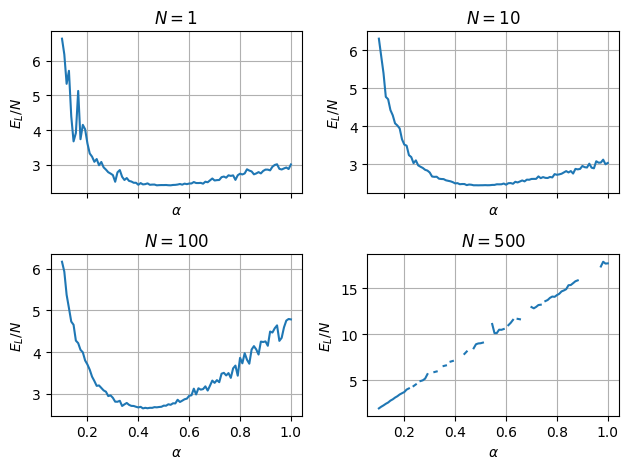

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_repulsive import BoseParamGrid
from bose_repulsive_jax import wavefunction_jax, local_energy_jax, BoseParams

base_cycles = 10_000
base_step = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
beta_values = np.array([2.82843])
a_values = np.array([0.0043])

param_grid = BoseParamGrid(
  param_type=BoseParams,
  alpha=alpha_values,
  beta=beta_values,
  gamma=beta_values,
  a=a_values,
)

number_particles = [1, 10, 100, 500]
dim = 3

fig, axs = plt.subplots(2, 2, sharex=True)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  simulation = MetropolisJAX[BoseParams](n, dim)
  result = simulation.grid_search_brute(
    wavefunction_jax, local_energy_jax, param_grid, base_step, base_cycles
  )

  energies = result.energies
  ax.plot(alpha_values, energies / n)
  ax.set_title(f"$N = {n}$")
  ax.set(xlabel=r"$\alpha$", ylabel=r"$E_L /N$")
  ax.grid(True)

  min_energy = np.min(energies)
  min_alpha = alpha_values[np.argmin(energies)]
  print(f"Results for N = {n} (3D):")
  print(f"Minimum energy: {min_energy:.2f}")
  print(f"Minimum alpha: {min_alpha:.2f}\n")

plt.tight_layout()
plt.show()


In [4]:
import jax
print(jax.default_backend())

gpu
